#  E-Commerce Sales Data Analysis

## 1. Introduction

###  Problem Statement
The e-commerce company is facing multiple operational challenges such as high cancellation rates, inefficient logistics, and lack of insights into customer behavior. The goal is to analyze sales data and generate actionable insights to improve business performance.

###  Objective
- Analyze financial performance (revenue trends)
- Identify top-performing products and categories
- Understand customer behavior (B2B vs B2C)
- Analyze geographical sales distribution
- Evaluate operational efficiency (delivery & cancellations)
- Provide business recommendations

## 2. Data Understanding

###  Dataset Overview
The dataset contains transactional data from an e-commerce platform, including order details, customer information, product details, and shipping data.

This dataset will help analyze:
- Revenue trends
- Product performance
- Customer behavior
- Operational efficiency

###  Column Description

| Column Name | Description |
|------------|------------|
| Order ID | Unique identifier for each order |
| Date | Order date |
| Status | Order status (Shipped, Cancelled, Delivered, etc.) |
| Fulfilment | Fulfillment method (Amazon / Merchant) |
| Sales Channel | Platform of sale |
| Category | Product category |
| Size | Product size |
| Qty | Quantity ordered |
| Amount | Order value |
| ship-city/state/country | Shipping location |
| B2B | Business customer flag |
| Courier Status | Shipping status |


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# load dataset
df = pd.read_csv('/content/sales_dataset.csv')

# preview data
df.head()

/tmp/ipykernel_7328/2992984462.py:11: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/sales_dataset.csv')


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [ ]:
# shape of dataset
df.shape

(128949, 23)

In [ ]:
#Information About Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128949 non-null  object 
 1   Date                128949 non-null  object 
 2   Status              128949 non-null  object 
 3   Fulfilment          128949 non-null  object 
 4   Sales Channel       128949 non-null  object 
 5   ship-service-level  128949 non-null  object 
 6   Style               128949 non-null  object 
 7   SKU                 128949 non-null  object 
 8   Category            128949 non-null  object 
 9   Size                128949 non-null  object 
 10  ASIN                128949 non-null  object 
 11  Courier Status      122078 non-null  object 
 12  Qty                 128949 non-null  int64  
 13  currency            121155 non-null  object 
 14  Amount              121155 non-null  float64
 15  ship-city           128916 non-nul

In [ ]:
#Description About Dataset
df.describe()

,Qty,Amount,ship-postal-code
count,128949.000000,121155.000000,128916.000000
mean,0.904629,648.550806,463978.298008
std,0.314782,281.218324,191473.322953
min,0.000000,0.000000,110001.000000
25%,1.000000,449.000000,382421.000000
50%,1.000000,605.000000,500033.000000
75%,1.000000,788.000000,600024.000000
max,15.000000,5584.000000,989898.000000


In [ ]:
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].nunique(), "unique values")
    print(df[col].unique()[:10])


Column: Order ID
120352 unique values
['405-8078784-5731545' '171-9198151-1101146' '404-0687676-7273146'
 '403-9615377-8133951' '407-1069790-7240320' '404-1490984-4578765'
 '408-5748499-6859555' '406-7807733-3785945' '407-5443024-5233168'
 '402-4393761-0311520']

Column: Date
91 unique values
['04-30-22' '04-29-22' '04-28-22' '04-27-22' '04-26-22' '04-25-22'
 '04-24-22' '04-23-22' '04-22-22' '04-21-22']

Column: Status
13 unique values
['Cancelled' 'Shipped - Delivered to Buyer' 'Shipped'
 'Shipped - Returned to Seller' 'Shipped - Rejected by Buyer'
 'Shipped - Lost in Transit' 'Shipped - Out for Delivery'
 'Shipped - Returning to Seller' 'Shipped - Picked Up' 'Pending']

Column: Fulfilment
2 unique values
['Merchant' 'Amazon']

Column: Sales Channel 
2 unique values
['Amazon.in' 'Non-Amazon']

Column: ship-service-level
2 unique values
['Standard' 'Expedited']

Column: Style
1377 unique values
['SET389' 'JNE3781' 'JNE3371' 'J0341' 'JNE3671' 'SET264' 'J0095' 'JNE3405'
 'SET200' 'JNE34

In [ ]:
# check missing values
df.isnull().sum()

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


In [ ]:
print("Unique Order IDs:", df['Order ID'].nunique())
print("Total Rows:", len(df))

df['Order ID'].isnull().sum()

Unique Order IDs: 120352
Total Rows: 128949


np.int64(0)

In [ ]:
df[df.duplicated('Order ID')]

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
32,403-4367956-2849158,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3543,JNE3543-KR-S,kurta,S,B08HHJP41L,Shipped,1,INR,368.0,NEW DELHI,DELHI,110092.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
56,404-2262140-4696366,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3579,JNE3579-KR-M,kurta,M,B08QGK2BS2,Shipped,1,INR,295.0,NAGPUR,MAHARASHTRA,440022.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
74,408-4069830-3819562,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET394,SET394-KR-NP-XXXL,Set,3XL,B09TH6R8K4,Shipped,1,INR,1281.0,Kolkata,WEST BENGAL,700048.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
75,408-4069830-3819562,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET397,SET397-KR-NP-XXXL,Set,3XL,B09RKDPH6J,Shipped,1,INR,1186.0,Kolkata,WEST BENGAL,700048.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
97,405-5257740-5301158,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3439,JNE3439-KR-XL,kurta,XL,B081X4KQ14,Shipped,1,INR,399.0,ROHTAK,HARYANA,124001.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128853,405-4724097-1016369,06-01-2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0009,J0009-SKD-S,Set,S,B0894X8979,Shipped,1,INR,854.0,ALLUR,ANDHRA PRADESH,524315.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
128887,403-6757403-6097100,05-31-22,Cancelled,Amazon,Amazon.in,Expedited,NW007,NW007-ST-CP-XXXL,Set,3XL,B0928YCMQP,Cancelled,0,NaN,NaN,GREATER NOIDA,UTTAR PRADESH,201306.0,IN,NaN,False,NaN,False
128909,407-8519205-5064368,05-31-22,Shipped,Amazon,Amazon.in,Expedited,SET324,SET324-KR-NP-XL,Set,XL,B09NQ4QS13,Shipped,1,INR,635.0,VIJAYAWADA,ANDHRA PRADESH,520010.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
128916,403-3035549-4142738,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0301,J0301-TP-XXL,Top,XXL,B099S8X47K,Shipped,1,INR,518.0,BENGALURU,KARNATAKA,560102.0,IN,NaN,False,NaN,False


Order ID Analysis:
 - No missing values found
 - Duplicate Order IDs exist
 - These duplicates represent multiple items in a single order (valid scenario)
- Therefore, duplicates are NOT removed

In [ ]:
df['Order ID'].value_counts().head()

,count
Order ID,
403-4984515-8861958,12
171-5057375-2831560,12
403-0173977-3041148,11
404-9932919-6662730,11
408-3317403-1729937,10


In [ ]:
print(df['Date'].head())

print("Null values:", df['Date'].isnull().sum())
print("Unique values:", df['Date'].nunique())

0    04-30-22
1    04-30-22
2    04-30-22
3    04-30-22
4    04-30-22
Name: Date, dtype: object
Null values: 0
Unique values: 91


In [ ]:
df['Date'] = df['Date'].astype(str).str.strip()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

/tmp/ipykernel_7328/705853587.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [ ]:
print("Null after conversion:", df['Date'].isnull().sum())
print("Min Date:", df['Date'].min())
print("Max Date:", df['Date'].max())

Null after conversion: 0
Min Date: 2022-03-31 00:00:00
Max Date: 2022-06-29 00:00:00


In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day
df['Day_Name'] = df['Date'].dt.day_name()

In [ ]:
print(df['Month_Name'].value_counts())

Month_Name
April    49058
May      42035
June     37685
March      171
Name: count, dtype: int64


 Date Column Analysis:
 - Converted Date to datetime after cleaning
 - Extracted Year, Month, Month_Name, Day, Day_Name
 - Dataset contains data from March to June only
 - No missing values in Date column

In [ ]:
month_order = ['March', 'April', 'May', 'June']

df['Month_Name'] = pd.Categorical(df['Month_Name'], categories=month_order, ordered=True)

In [ ]:
df['Month_Name'].value_counts().sort_index()

,count
Month_Name,
March,171
April,49058
May,42035
June,37685


In [ ]:
df['Status'].value_counts()

,count
Status,
Shipped,77767
Shipped - Delivered to Buyer,28771
Cancelled,18341
Shipped - Returned to Seller,1953
Shipped - Picked Up,973
Pending,658
Pending - Waiting for Pick Up,281
Shipped - Returning to Seller,145
Shipped - Out for Delivery,35


In [ ]:
df['Status'].isnull().sum()

np.int64(0)

In [ ]:
df['Status'] = df['Status'].str.lower().str.strip()

In [ ]:
def clean_status(x):
    x = str(x).strip().lower()

    if x == 'shipped':
        return 'Shipped'
    elif x == 'cancelled':
        return 'Cancelled'
    elif x == 'pending':
        return 'Pending'

    elif x == 'shipped - delivered to buyer':
        return 'Shipped'
    elif x == 'shipped - returned to seller':
        return 'Cancelled'
    elif x == 'shipped - returning to seller':
        return 'Cancelled'
    elif x == 'shipped - rejected by buyer':
        return 'Cancelled'
    elif x == 'shipped - damaged':
        return 'Damaged'

    elif x == 'shipped - picked up':
        return 'Pending'
    elif x == 'pending - waiting for pick up':
        return 'Pending'
    elif x == 'shipping':
        return 'Pending'

    elif x == 'shipped - lost in transit':
        return 'Unknown'

    elif x == 'shipped - out for delivery':
        return 'Shipped'

    else:
        return 'Unknown'

df['Status_Clean'] = df['Status'].apply(clean_status)

In [ ]:
df['Status_Clean'].value_counts()

,count
Status_Clean,
Shipped,106573
Cancelled,20450
Pending,1920
Unknown,5
Damaged,1


In [ ]:
cancelled_orders = df[df['Status'].str.lower().str.strip() == 'cancelled']['Order ID'].nunique()

total_orders = df['Order ID'].nunique()

cancellation_rate = (cancelled_orders / total_orders) * 100

print("Total Orders:", total_orders)
print("Cancelled Orders:", cancelled_orders)
print("Cancellation Rate:", round(cancellation_rate, 2))

Total Orders: 120352
Cancelled Orders: 17196
Cancellation Rate: 14.29


 Status Column Analysis:
 - Original column had multiple variations of shipping states
 - Grouped into 4 main categories: Shipped, Cancelled, Pending and Unknown
 - All shipment-related statuses grouped under 'Shipped'

In [ ]:
df['Fulfilment'].value_counts()

,count
Fulfilment,
Amazon,89679
Merchant,39270


In [ ]:
df['Fulfilment'].isnull().sum()

np.int64(0)

In [ ]:
df['Fulfilment'] = df['Fulfilment'].str.strip().str.title()

 Fulfilment Column Analysis:
 - Contains two values: Amazon and Merchant
 - No missing values found
 - Cleaned text formatting for consistency
 - No further transformation required

In [ ]:
df['Sales Channel '].value_counts()

,count
Sales Channel,
Amazon.in,128825
Non-Amazon,124


In [ ]:
df['Sales Channel '].isnull().sum()

np.int64(0)

In [ ]:
df['Sales Channel '] = df['Sales Channel '].str.strip()

 Sales Channel Column Analysis:
 - Contains two values: Amazon.in and Non-Amazon
 - No missing values found
 - Highly imbalanced distribution (majority Amazon.in)
 - Column retained for analysis

In [ ]:
df['ship-service-level'].value_counts()

,count
ship-service-level,
Expedited,88596
Standard,40353


In [ ]:
df['ship-service-level'].isnull().sum()

np.int64(0)

In [ ]:
df['ship-service-level'] = df['ship-service-level'].str.strip().str.title()

In [ ]:
df['ship-service-level'].value_counts()

,count
ship-service-level,
Expedited,88596
Standard,40353


 ship-service-level Analysis:
 - Checked unique values (Standard, Expedited)
 - No missing values (or filled using mode)
 - Cleaned formatting for consistency
 - Column useful for logistics insights

In [ ]:
df['Style'].value_counts().head(10)

,count
Style,
JNE3797,4224
JNE3405,2262
J0230,1868
SET268,1860
J0341,1630
J0003,1627
SET324,1284
SET345,1250
JNE3373,1173


In [ ]:
df['Style'].nunique()

1377

In [ ]:
df['Style'].isnull().sum()

np.int64(0)

 Style Column Analysis:
 - Contains high number of unique product identifiers
 - No missing values found
 - Used for product-level analysis
 - No transformation required

In [ ]:
df['SKU'].value_counts().head(10)

,count
SKU,
JNE3797-KR-L,773
JNE3797-KR-M,657
JNE3797-KR-S,587
JNE3405-KR-L,535
J0230-SKD-M,507
JNE3797-KR-XL,474
J0230-SKD-S,452
JNE3405-KR-S,443
JNE3797-KR-XS,431


In [ ]:
df['SKU'].isnull().sum()

np.int64(0)

In [ ]:
(df['SKU'] == '').sum()

np.int64(0)

In [ ]:
df['SKU'].duplicated().sum()

np.int64(121754)

In [ ]:
df['Category'].value_counts()

,count
Category,
Set,50275
kurta,49867
Western Dress,15495
Top,10621
Ethnic Dress,1158
Blouse,926
Bottom,440
Saree,164
Dupatta,3


In [ ]:
df['Category'].isnull().sum()

np.int64(0)

In [ ]:
df['Category'] = df['Category'].str.strip().str.title()

In [ ]:
df['Category'].value_counts()

,count
Category,
Set,50275
Kurta,49867
Western Dress,15495
Top,10621
Ethnic Dress,1158
Blouse,926
Bottom,440
Saree,164
Dupatta,3


 Category Column Analysis:
 - Contains limited number of product categories
 - Cleaned formatting inconsistencies (case & spacing)


In [ ]:
df['Size'].value_counts().head(15)

,count
Size,
M,22705
L,22124
XL,20879
XXL,18089
S,17092
3XL,14811
XS,11157
6XL,737
5XL,550


In [ ]:
df['Size'].isnull().sum()

np.int64(0)

In [ ]:
df['Size'] = df['Size'].str.strip().str.upper()

In [ ]:
df['Size'].value_counts()

,count
Size,
M,22705
L,22124
XL,20879
XXL,18089
S,17092
3XL,14811
XS,11157
6XL,737
5XL,550


 Size Column Analysis:
 - Contains categorical values (S, M, L, XL, etc.)
 - Standardized format using uppercase
 - Column useful for product and inventory analysis

In [ ]:
df['ASIN'].value_counts().head(10)

,count
ASIN,
B09SDXFFQ1,773
B09SDY8DCT,657
B09SDYQ3WG,587
B081WSCKPQ,535
B08XNJG8B1,507
B09SDXRYBG,474
B08XNJ19QH,452
B081WX4G4Q,443
B09SDY9SQ6,431


In [ ]:
df['ASIN'].nunique()

7190

In [ ]:
df['ASIN'].isnull().sum()

np.int64(0)

In [ ]:
(df['ASIN'] == '').sum()

np.int64(0)

In [ ]:
df['ASIN'].duplicated().sum()

np.int64(121759)

 ASIN Column Analysis:
 - High number of unique product identifiers
 - Duplicate values expected due to repeated sales
 - No transformation required

In [ ]:
df['Courier Status'].value_counts()

,count
Courier Status,
Shipped,109463
Unshipped,6681
Cancelled,5934


In [ ]:
df['Courier Status'].isnull().sum()

np.int64(6871)

In [ ]:
df['Courier Status'] = df['Courier Status'].fillna('Unknown')

In [ ]:
df['Courier Status'] = df['Courier Status'].str.strip().str.title()

In [ ]:
df['Courier Status'].value_counts()

,count
Courier Status,
Shipped,109463
Unknown,6871
Unshipped,6681
Cancelled,5934


 Courier Status Analysis:
 - Contains shipment status (Shipped, Unknown, Cancelled, Unshipped)
 - Cleaned formatting for consistency
 - Important for logistics and delivery analysis

In [ ]:
df['Qty'].describe()

,Qty
count,128949.000000
mean,0.904629
std,0.314782
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,15.000000


In [ ]:
df['Qty'].isnull().sum()

np.int64(0)

In [ ]:
(df['Qty'] == 0).sum()

np.int64(12810)

In [ ]:
(df['Qty'] <0).sum()

np.int64(0)

In [ ]:
df['currency'].value_counts()

,count
currency,
INR,121155


In [ ]:
df['currency'].isnull().sum()

np.int64(7794)

In [ ]:
df['currency'] = df['currency'].fillna('INR')

In [ ]:
df['currency'] = df['currency'].replace('', 'INR')

 Currency Column Analysis:
 - Majority values are INR
 - Missing and blank values filled with INR
 - Standardized formatting
 - Column retained for consistency

In [ ]:
df['Amount'].isnull().sum()

np.int64(7794)

In [ ]:
# Convert amount
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce').fillna(0)

# Remove cancelled revenue
df.loc[df['Status'].str.lower().str.strip() == 'cancelled', 'Amount'] = 0

# 🔥 KEY FIX → aggregate at order level
order_revenue = df.groupby('Order ID')['Amount'].sum()

total_revenue = order_revenue.sum()

print("Total Revenue (M):", round(total_revenue / 1e6, 2))

Total Revenue (M): 71.65


In [ ]:
df['Amount'].isnull().sum()

np.int64(0)

 Amount Column Analysis:
 - Converted Amount to numeric format
 - Set Amount = 0 for cancelled orders (business rule)
 - Calculated median of Amount column
 - Missing values filled using median
 - Preserved zero values as valid entries

In [ ]:
df['ship-city'].value_counts().head(10)

,count
ship-city,
BENGALURU,11212
HYDERABAD,8071
MUMBAI,6124
NEW DELHI,5793
CHENNAI,5419
PUNE,3856
KOLKATA,2381
GURUGRAM,1867
THANE,1701


In [ ]:
df['ship-city'].isnull().sum()

np.int64(33)

In [ ]:
df = df.dropna(subset=['ship-city'])

In [ ]:
df['ship-city'] = df['ship-city'].astype(str).str.strip().str.title()

 ship-city Column Analysis:
 - Cleaned inconsistent city name formatting
 - Converted all values to title case
 - Empty values deleted
 - Column prepared for geographical analysis

In [ ]:
df['ship-state'].value_counts()

,count
ship-state,
MAHARASHTRA,22257
KARNATAKA,17321
TAMIL NADU,11481
TELANGANA,11327
UTTAR PRADESH,10636
DELHI,6780
KERALA,6585
WEST BENGAL,5962
ANDHRA PRADESH,5429


In [ ]:
df['ship-state'].isnull().sum()

np.int64(0)

In [ ]:
(df['ship-state'] == '').any()

np.False_

In [ ]:
df['ship-state'] = df['ship-state'].astype(str).str.strip().str.title()

In [ ]:
df['ship-state'].value_counts()

,count
ship-state,
Maharashtra,22257
Karnataka,17321
Tamil Nadu,11481
Telangana,11327
Uttar Pradesh,10636
Delhi,6964
Kerala,6585
West Bengal,5962
Andhra Pradesh,5429


In [ ]:
state_mapping = {

    'New Delhi': 'Delhi',
    'Orissa': 'Odisha',
    'Pondicherry': 'Puducherry',


    'Rajshthan': 'Rajasthan',
    'Rajsthan': 'Rajasthan',


    'Rj': 'Rajasthan',
    'Pb': 'Punjab',
    'Nl': 'Nagaland',


    'Punjab/Mohali/Zirakpur': 'Punjab',


    'Dadra And Nagar': 'Dadra And Nagar Haveli',


    'Apo': 'Unknown',
    'Ar': 'Unknown'
}

df['ship-state'] = df['ship-state'].replace(state_mapping)

In [ ]:
df['ship-state'].value_counts()

,count
ship-state,
Maharashtra,22257
Karnataka,17321
Tamil Nadu,11481
Telangana,11327
Uttar Pradesh,10636
Delhi,7045
Kerala,6585
West Bengal,5962
Andhra Pradesh,5429


In [ ]:
df = df[df['ship-state'] != 'Unknown']

 ship-state Column Analysis:
 - Standardized state names using title case
 - Fixed spelling errors and abbreviations (e.g., Rj → Rajasthan)
 - Merged duplicate representations (e.g., New Delhi → Delhi)
 - Handled invalid entries by mapping to 'Unknown'
 - APO, AR - Unknown, while their value count is = 2, thus dropped.
 - Ensured data integrity by avoiding incorrect assumptions

In [ ]:
df['ship-country'].value_counts()

,count
ship-country,
IN,128914


In [ ]:
df['ship-country'].isnull().sum()

np.int64(0)

In [ ]:
df['ship-country'] = df['ship-country'].fillna('IN')

In [ ]:
df['ship-country'] = df['ship-country'].replace(' ', 'IN')

In [ ]:
df['ship-country'] = df['ship-country'].str.strip().str.upper()

In [ ]:
df['ship-country'].value_counts()

,count
ship-country,
IN,128914


 ship-country Column Analysis:
 - Contains only one value (IN)
 - Missing values filled with IN
 - No variation in data
 - Column can be dropped as it adds no analytical value

In [ ]:
df['ship-postal-code'].describe()

,ship-postal-code
count,128914.000000
mean,463971.919512
std,191467.674041
min,110001.000000
25%,382421.000000
50%,500033.000000
75%,600024.000000
max,989898.000000


In [ ]:
df['ship-postal-code'].isnull().sum()

np.int64(0)

In [ ]:
df['ship-postal-code'] = df['ship-postal-code'].astype(int).astype(str)

In [ ]:
df['ship-postal-code'].value_counts().head()

,count
ship-postal-code,
201301,1006
122001,688
560037,632
560068,619
560076,581


 ship-postal-code Analysis:
 - Converted postal code to string format
 - No Null Found
 - Treated as categorical identifier, not numeric
 - No further transformation required

In [ ]:
df['promotion-ids'].value_counts().head()

,count
promotion-ids,
IN Core Free Shipping 2015/04/08 23-48-5-108,46077
Duplicated A12RHGVGRWOT3S 1560498941486,488
"Amazon PLCC Free-Financing Universal Merchant AAT-WNKTBO3K27EJC,Amazon PLCC Free-Financing Universal Merchant AAT-QX3UCCJESKPA2,Amazon PLCC Free-Financing Universal Merchant AAT-CXJHMC2YJUK76,Amazon PLCC Free-Financing Universal Merchant AAT-CC4FAVTYR4X7C,Amazon PLCC Free-Financing Universal Merchant AAT-XXRCW6NZEPZI4,Amazon PLCC Free-Financing Universal Merchant AAT-EOKPWFWYW7Y6I,Amazon PLCC Free-Financing Universal Merchant AAT-ZYL5UPUNW6T62,Amazon PLCC Free-Financing Universal Merchant AAT-G5ZRX4BZOIODU,Amazon PLCC Free-Financing Universal Merchant AAT-PZHUW6DZX4BPS,Amazon PLCC Free-Financing Universal Merchant AAT-XX7G3ZRJJJ5LG,Amazon PLCC Free-Financing Universal Merchant AAT-LEHCKNDBJG64E,Amazon PLCC Free-Financing Universal Merchant AAT-DJVHCEV7D7RQY,Amazon PLCC Free-Financing Universal Merchant AAT-BRSZZ45H6MHAO,Amazon PLCC Free-Financing Universal Merchant AAT-MKLXOOZWQL7GO,Amazon PLCC Free-Financing Universal Merchant AAT-CB7UNXEXGIJTC,Amazon PLCC Free-Financing Universal Merchant #MP-gzasho-1593152694811,Amazon PLCC Free-Financing Universal Merchant AAT-WLBA4GZ52EAH4",458
Duplicated AYTJSBA8ZOP16 1567159860988,433
"Amazon PLCC Free-Financing Universal Merchant AAT-WNKTBO3K27EJC,Amazon PLCC Free-Financing Universal Merchant AAT-QX3UCCJESKPA2,Amazon PLCC Free-Financing Universal Merchant AAT-5QQ7BIYYQEDN2,Amazon PLCC Free-Financing Universal Merchant AAT-DSJ2QRXXWXVMQ,Amazon PLCC Free-Financing Universal Merchant AAT-CXJHMC2YJUK76,Amazon PLCC Free-Financing Universal Merchant AAT-CC4FAVTYR4X7C,Amazon PLCC Free-Financing Universal Merchant AAT-XXRCW6NZEPZI4,Amazon PLCC Free-Financing Universal Merchant AAT-EOKPWFWYW7Y6I,Amazon PLCC Free-Financing Universal Merchant AAT-ZYL5UPUNW6T62,Amazon PLCC Free-Financing Universal Merchant AAT-G5ZRX4BZOIODU,Amazon PLCC Free-Financing Universal Merchant AAT-PZHUW6DZX4BPS,Amazon PLCC Free-Financing Universal Merchant AAT-ETXQ3XXWMRXBG,Amazon PLCC Free-Financing Universal Merchant AAT-BRSZZ45H6MHAO,Amazon PLCC Free-Financing Universal Merchant AAT-MKLXOOZWQL7GO,Amazon PLCC Free-Financing Universal Merchant AAT-CB7UNXEXGIJTC,Amazon PLCC Free-Financing Universal Merchant #MP-gzasho-1593152694811,Amazon PLCC Free-Financing Universal Merchant AAT-WLBA4GZ52EAH4",316


In [ ]:
df['promotion-ids'].isnull().sum()

np.int64(49132)

In [ ]:
df['promotion-ids'] = df['promotion-ids'].fillna('Unknown')

In [ ]:
(df['promotion-ids'] == '').any()

np.False_

In [ ]:
df['promotion-ids'] = df['promotion-ids'].str.strip()

In [ ]:
df['promotion-ids'].value_counts().head()


,count
promotion-ids,
Unknown,49132
IN Core Free Shipping 2015/04/08 23-48-5-108,46077
Duplicated A12RHGVGRWOT3S 1560498941486,488
"Amazon PLCC Free-Financing Universal Merchant AAT-WNKTBO3K27EJC,Amazon PLCC Free-Financing Universal Merchant AAT-QX3UCCJESKPA2,Amazon PLCC Free-Financing Universal Merchant AAT-CXJHMC2YJUK76,Amazon PLCC Free-Financing Universal Merchant AAT-CC4FAVTYR4X7C,Amazon PLCC Free-Financing Universal Merchant AAT-XXRCW6NZEPZI4,Amazon PLCC Free-Financing Universal Merchant AAT-EOKPWFWYW7Y6I,Amazon PLCC Free-Financing Universal Merchant AAT-ZYL5UPUNW6T62,Amazon PLCC Free-Financing Universal Merchant AAT-G5ZRX4BZOIODU,Amazon PLCC Free-Financing Universal Merchant AAT-PZHUW6DZX4BPS,Amazon PLCC Free-Financing Universal Merchant AAT-XX7G3ZRJJJ5LG,Amazon PLCC Free-Financing Universal Merchant AAT-LEHCKNDBJG64E,Amazon PLCC Free-Financing Universal Merchant AAT-DJVHCEV7D7RQY,Amazon PLCC Free-Financing Universal Merchant AAT-BRSZZ45H6MHAO,Amazon PLCC Free-Financing Universal Merchant AAT-MKLXOOZWQL7GO,Amazon PLCC Free-Financing Universal Merchant AAT-CB7UNXEXGIJTC,Amazon PLCC Free-Financing Universal Merchant #MP-gzasho-1593152694811,Amazon PLCC Free-Financing Universal Merchant AAT-WLBA4GZ52EAH4",458
Duplicated AYTJSBA8ZOP16 1567159860988,433


 promotion-ids Column Analysis:
 - Contains promotion identifiers for discounted orders
 - Missing values represent Unknown applied
 - NO null and blank values Found
 - Cleaned formatting for consistency

In [ ]:
df['B2B'].value_counts()

,count
B2B,
False,128043
True,871


In [ ]:
df['B2B'].isnull().sum()

np.int64(0)

In [ ]:
df['Customer_Type'] = df['B2B'].map({ True: 'B2B', False: 'B2C'})

In [ ]:
df['Customer_Type'].value_counts()

,count
Customer_Type,
B2C,128043
B2B,871


 B2B Column Analysis:
 - Contains boolean values indicating business (B2B) or consumer (B2C)
 - Missing values filled with False (assumed B2C)
 - Created new column 'Customer_Type' for better readability

In [ ]:
df['fulfilled-by'].value_counts()

,count
fulfilled-by,
Easy Ship,39257


In [ ]:
df['fulfilled-by'].isnull().sum()

np.int64(89657)

In [ ]:
df['fulfilled-by'] = df['fulfilled-by'].fillna('Merchant')

In [ ]:
df['fulfilled-by'] = df['fulfilled-by'].astype(str).str.strip()

In [ ]:
df['fulfilled-by'] = df['fulfilled-by'].replace({
    'Easy Ship': 'Amazon',
    '': 'Merchant'
})


In [ ]:
df['fulfilled-by'].value_counts()

,count
fulfilled-by,
Merchant,89657
Amazon,39257


 fulfilled-by Column Analysis:
 - 'Easy Ship' represents Amazon fulfillment
 - Missing/blank values represent Merchant fulfillment. As if we dont know who fulfilled then it must be some Merchant, so Unknown = Merchant.
 - Cleaned and standardized values into 'Amazon' and 'Merchant'
 - Column prepared for logistics analysis

In [ ]:
df['Unnamed: 22'].value_counts()

,count
Unnamed: 22,
False,79887


In [ ]:
df['Unnamed: 22'].describe()

,Unnamed: 22
count,79887
unique,1
top,False
freq,79887


In [ ]:
df['Unnamed: 22'].info()

<class 'pandas.core.series.Series'>
Index: 128914 entries, 0 to 128948
Series name: Unnamed: 22
Non-Null Count  Dtype 
--------------  ----- 
79887 non-null  object
dtypes: object(1)
memory usage: 2.0+ MB


In [ ]:
df['Unnamed: 22'].head()

,Unnamed: 22
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


In [ ]:
df['Unnamed: 22'].isnull().sum()

np.int64(49027)

In [ ]:
df = df.drop(columns=['Unnamed: 22'])

In [ ]:
df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Year', 'Month', 'Month_Name', 'Day', 'Day_Name',
       'Status_Clean', 'Customer_Type'],
      dtype='object')

-------------------------------------

# FINANCIAL PERFORMANCE ANALYSIS

Analyzing total revenue growth over time.

In [ ]:
total_revenue = df['Amount'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 71631919.62


In [ ]:
monthly_revenue = df.groupby(['Year', 'Month', 'Month_Name'], as_index=False, observed=True)['Amount'].sum()

monthly_revenue = monthly_revenue.sort_values(by=['Year', 'Month'])

monthly_revenue['Month_Name'] = pd.Categorical(
    monthly_revenue['Month_Name'],
    categories=monthly_revenue.sort_values('Month')['Month_Name'].unique(),
    ordered=True
)

In [ ]:
monthly_sales = df.groupby('Month_Name')['Amount'].sum().sort_values(ascending=False).reset_index()
monthly_sales.head()

/tmp/ipykernel_7328/2720884764.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = df.groupby('Month_Name')['Amount'].sum().sort_values(ascending=False).reset_index()


,Month_Name,Amount
0,April,26221964.62
1,May,23937184.00
2,June,21377961.00
3,March,94810.00


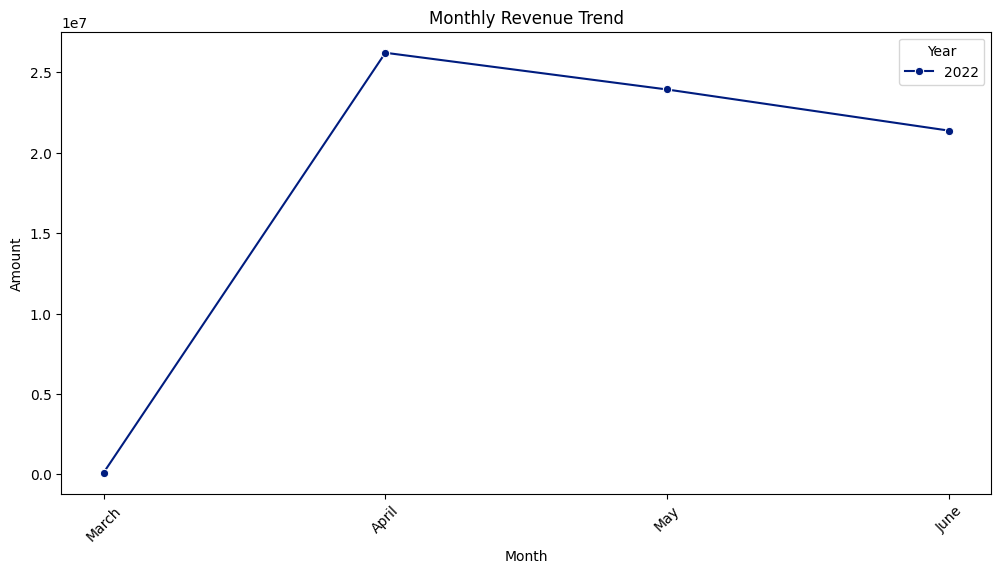

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_revenue,
    x='Month_Name',
    y='Amount',
    hue='Year',
    marker='o',
    palette='dark'   # darker colors
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()

WEEKLY SALES TREND

In [ ]:
weekly_sales = df.groupby('Day_Name')['Amount'].sum().reset_index()

# correct order
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekly_sales['Day_Name'] = pd.Categorical(
    weekly_sales['Day_Name'],
    categories=day_order,
    ordered=True
)

In [ ]:
weekly_sales = weekly_sales.sort_values('Day_Name')

weekly_sales.head()

,Day_Name,Amount
1,Monday,10296755.0
5,Tuesday,10472594.0
6,Wednesday,10285291.0
4,Thursday,9476652.0
0,Friday,9839561.0


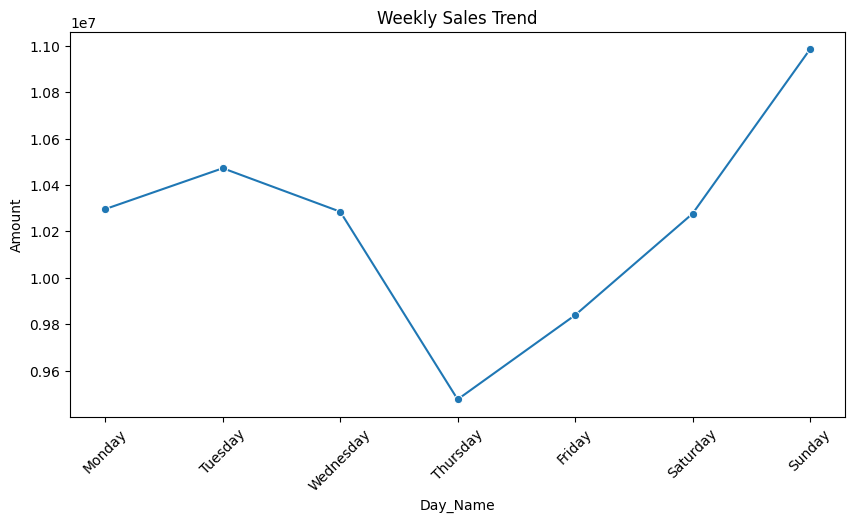

In [ ]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=weekly_sales,
    x='Day_Name',
    y='Amount',
    marker='o'
)

plt.title("Weekly Sales Trend")
plt.xticks(rotation=45)

plt.show()

Identifying best-selling products

In [ ]:
category_sales = df.groupby('Category')['Amount'].sum().sort_values(ascending=False).reset_index()
category_sales.head()

,Category,Amount
0,Set,35713959.14
1,Kurta,19412784.48
2,Western Dress,10202765.00
3,Top,4901444.00
4,Ethnic Dress,731516.00


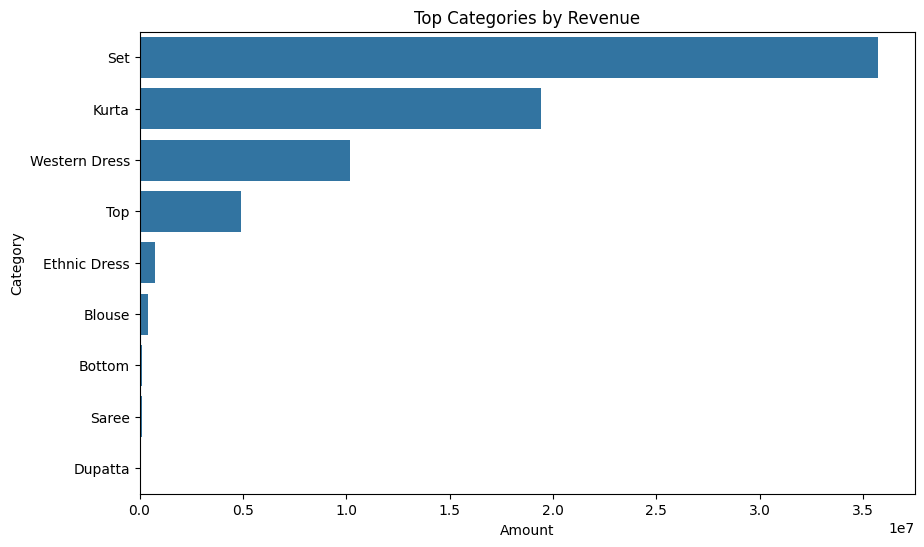

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=category_sales.head(10), x='Amount', y='Category')

plt.title("Top Categories by Revenue")
plt.show()

 CATEGORY SALES ANALYSIS




In [ ]:
top_products = df.groupby('SKU')['Amount'].sum().sort_values(ascending=False).head(10).reset_index()
top_products

,SKU,Amount
0,J0230-SKD-M,483611.0
1,JNE3797-KR-L,469312.0
2,J0230-SKD-S,448825.0
3,JNE3797-KR-M,403115.0
4,JNE3797-KR-S,360194.0
5,JNE3797-KR-XL,302519.0
6,J0230-SKD-L,277678.0
7,JNE3797-KR-XS,274609.0
8,SET268-KR-NP-XL,260156.0
9,JNE3797-KR-XXL,253211.0


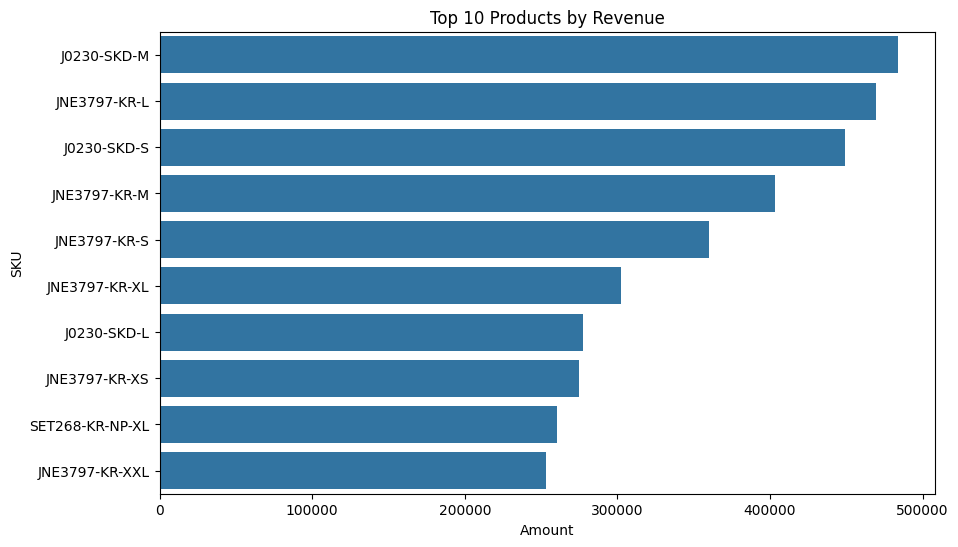

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_products, x='Amount', y='SKU')

plt.title("Top 10 Products by Revenue")
plt.show()

Calculating the average order value to
understand spending behavior.

Average Order Value (AOV) indicates the average spending per order. Higher AOV reflects better customer purchasing behavior and revenue efficiency.

In [ ]:
aov = df['Amount'].sum() / df['Order ID'].nunique()
print("Average Order Value:", aov)

Average Order Value: 595.3351807649474


# CUSTOMER INSIGHTS ANALYSIS

Identifying top-performing locations based
on sales volume.

In [ ]:
city_revenue = df.groupby('ship-city')['Amount'].sum().reset_index()

city_revenue = city_revenue.sort_values(by='Amount', ascending=False)

city_revenue.head(10)

,ship-city,Amount
809,Bengaluru,6724817.00
2539,Hyderabad,5082744.57
4330,Mumbai,3953150.00
4752,New Delhi,3634218.48
1313,Chennai,3294518.00
5487,Pune,2576637.00
3422,Kolkata,1547166.00
2336,Gurugram,1190303.00
6567,Thane,1015128.00
3784,Lucknow,957382.00


In [ ]:
top_cities = city_revenue.head(10)

print(top_cities)

      ship-city      Amount
809   Bengaluru  6724817.00
2539  Hyderabad  5082744.57
4330     Mumbai  3953150.00
4752  New Delhi  3634218.48
1313    Chennai  3294518.00
5487       Pune  2576637.00
3422    Kolkata  1547166.00
2336   Gurugram  1190303.00
6567      Thane  1015128.00
3784    Lucknow   957382.00


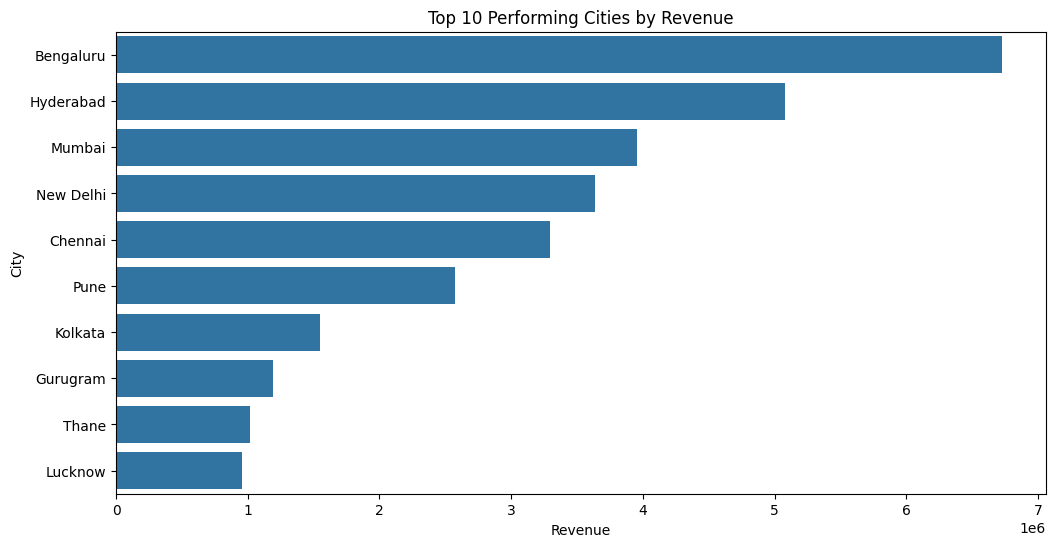

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_cities,
    x='Amount',
    y='ship-city'
)

plt.title("Top 10 Performing Cities by Revenue")
plt.xlabel("Revenue")
plt.ylabel("City")

plt.show()

BY STATE in ADDITION

In [ ]:
state_revenue = df.groupby('ship-state')['Amount'].sum().reset_index()

state_revenue = state_revenue.sort_values(by='Amount', ascending=False)

state_revenue.head(10)

,ship-state,Amount
20,Maharashtra,12221035.00
15,Karnataka,9645604.00
31,Telangana,6289838.57
33,Uttar Pradesh,6182323.00
30,Tamil Nadu,5952277.00
8,Delhi,4049679.48
16,Kerala,3376422.00
35,West Bengal,3205330.00
1,Andhra Pradesh,2881662.00
11,Haryana,2652267.00


Analyzing order cancellation trends and
customer retention.

Order Cancellation Trends

In [ ]:
total_orders = len(df)
cancelled_orders = len(df[df['Status_Clean'] == 'Cancelled'])

cancellation_rate = (cancelled_orders / total_orders) * 100

print("Cancellation Rate: {:.2f}%".format(cancellation_rate))

Cancellation Rate: 15.85%


MONTHLY CANCELLATION TREND

In [ ]:
monthly_cancel = df[df['Status_Clean'] == 'Cancelled'] \
    .groupby(['Month', 'Month_Name'], as_index=False)['Order ID'].count()

monthly_cancel = monthly_cancel.sort_values('Month')

print(monthly_cancel)

    Month Month_Name  Order ID
0       3      March        19
1       3      April         0
2       3        May         0
3       3       June         0
4       4      March         0
5       4      April      8034
6       4        May         0
7       4       June         0
8       5      March         0
9       5      April         0
10      5        May      6599
11      5       June         0
12      6      March         0
13      6      April         0
14      6        May         0
15      6       June      5787


/tmp/ipykernel_7328/688387222.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Month', 'Month_Name'], as_index=False)['Order ID'].count()


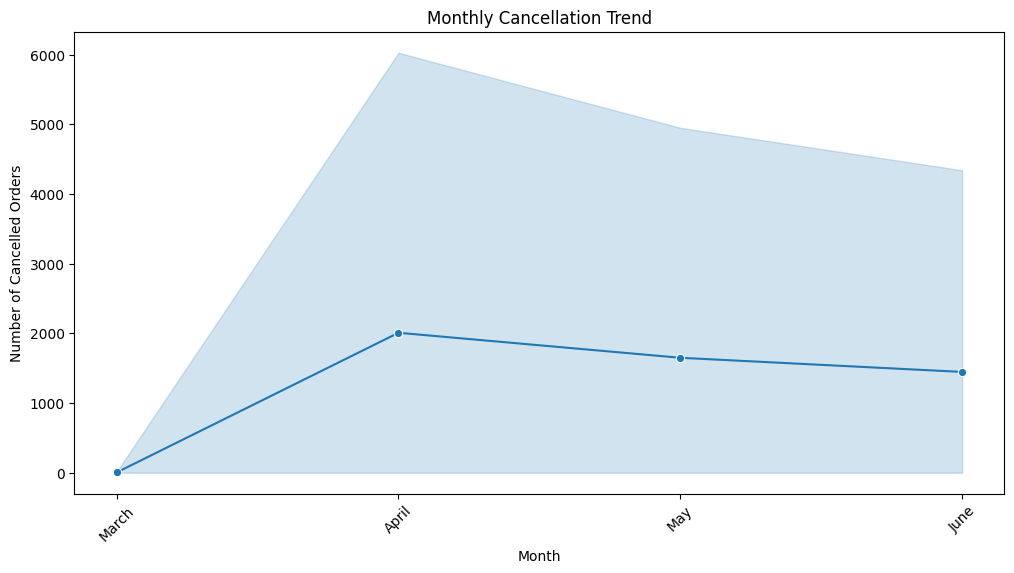

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_cancel,
    x='Month_Name',
    y='Order ID',
    marker='o'
)

plt.title("Monthly Cancellation Trend")
plt.xlabel("Month")
plt.ylabel("Number of Cancelled Orders")
plt.xticks(rotation=45)

plt.show()

Customer Retention Analysis

In [ ]:
customer_orders = df.groupby('Customer_Type')['Order ID'].count().reset_index()

print(customer_orders)

  Customer_Type  Order ID
0           B2B       871
1           B2C    128043


In [ ]:
customer_cancel = df[df['Status_Clean'] == 'Cancelled'] \
    .groupby('Customer_Type')['Order ID'].count().reset_index()

print(customer_cancel)

  Customer_Type  Order ID
0           B2B        82
1           B2C     20357


In [ ]:
successful_orders = df[df['Status_Clean'] == 'Shipped'] \
    .groupby('Customer_Type')['Order ID'].count().reset_index()

print(successful_orders)

  Customer_Type  Order ID
0           B2B       780
1           B2C    105769


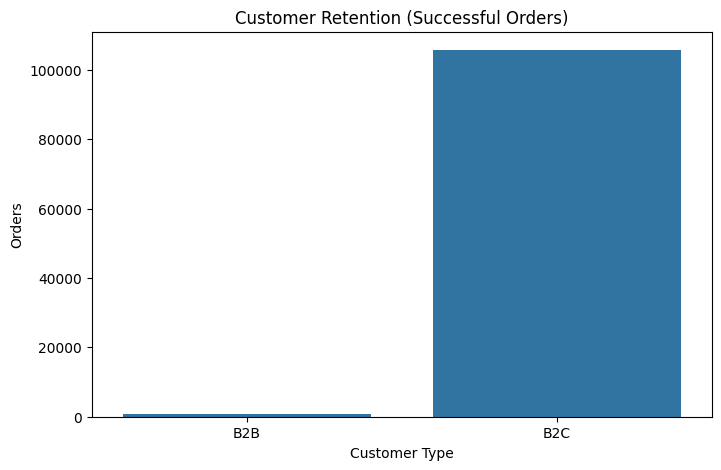

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=successful_orders,
    x='Customer_Type',
    y='Order ID'
)

plt.title("Customer Retention (Successful Orders)")
plt.xlabel("Customer Type")
plt.ylabel("Orders")

plt.show()

Differentiating B2B vs. B2C customer
behavior for targeted marketing.

In [ ]:
customer_orders = df.groupby('Customer_Type')['Order ID'].count().reset_index()

print(customer_orders)

  Customer_Type  Order ID
0           B2B       871
1           B2C    128043


In [ ]:
customer_revenue = df.groupby('Customer_Type')['Amount'].sum().reset_index()

print(customer_revenue)

  Customer_Type       Amount
0           B2B    559400.00
1           B2C  71072519.62


In [ ]:
customer_aov = df.groupby('Customer_Type')['Amount'].mean().reset_index()

print(customer_aov)

  Customer_Type      Amount
0           B2B  642.250287
1           B2C  555.067592


In [ ]:
customer_qty = df.groupby('Customer_Type')['Qty'].sum().reset_index()

print(customer_qty)

  Customer_Type     Qty
0           B2B     841
1           B2C  115781


In [ ]:
customer_cancel = df[df['Status_Clean'] == 'Cancelled'] \
    .groupby('Customer_Type')['Order ID'].count().reset_index()

print(customer_cancel)

  Customer_Type  Order ID
0           B2B        82
1           B2C     20357


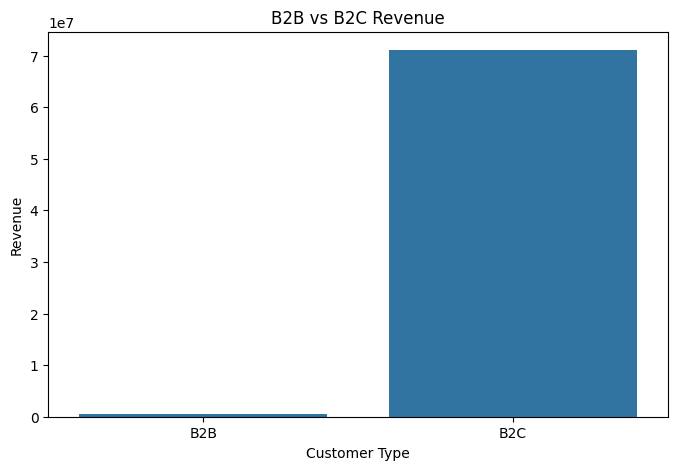

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=customer_revenue,
    x='Customer_Type',
    y='Amount'
)

plt.title("B2B vs B2C Revenue")
plt.xlabel("Customer Type")
plt.ylabel("Revenue")

plt.show()

# LOGISTICS & FULFILLMENT OPTIMIZATION

Addressing shipping delays by calculating
average shipping times.


In [ ]:
df['Shipping_Status'] = df['Status'].str.lower()

In [ ]:
delayed_orders = df[df['Shipping_Status'].str.contains('pending|waiting|returning|lost|damaged', na=False)]

print("Total Delayed Orders:", len(delayed_orders))

Total Delayed Orders: 1090


In [ ]:
total_orders = len(df)

delay_rate = (len(delayed_orders) / total_orders) * 100

print("Delay Rate: {:.2f}%".format(delay_rate))

Delay Rate: 0.85%


In [ ]:
monthly_delay = delayed_orders.groupby(['Month', 'Month_Name'], as_index=False)['Order ID'].count()

monthly_delay = monthly_delay.sort_values('Month')

print(monthly_delay)

    Month Month_Name  Order ID
0       4      March         0
1       4      April         5
2       4        May         0
3       4       June         0
4       5      March         0
5       5      April         0
6       5        May        25
7       5       June         0
8       6      March         0
9       6      April         0
10      6        May         0
11      6       June      1060


/tmp/ipykernel_7328/1414309612.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_delay = delayed_orders.groupby(['Month', 'Month_Name'], as_index=False)['Order ID'].count()


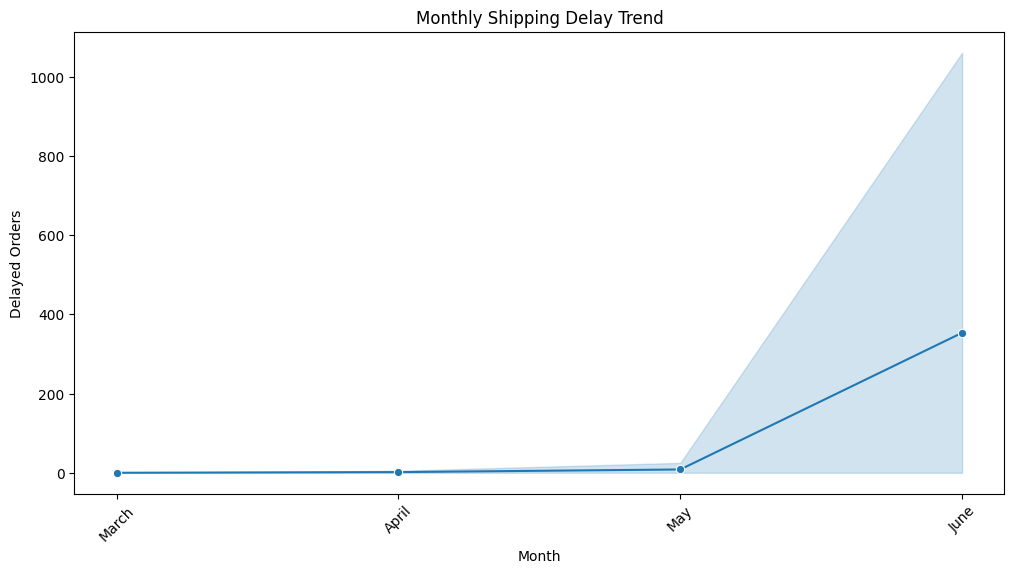

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_delay,
    x='Month_Name',
    y='Order ID',
    marker='o'
)

plt.title("Monthly Shipping Delay Trend")
plt.xlabel("Month")
plt.ylabel("Delayed Orders")
plt.xticks(rotation=45)

plt.show()

Comparing orders fulfilled by Amazon vs.
Merchant fulfillment.

In [ ]:
fulfilment_orders = df.groupby('Fulfilment')['Order ID'].count().reset_index()

print(fulfilment_orders)

  Fulfilment  Order ID
0     Amazon     89657
1   Merchant     39257


In [ ]:
fulfilment_revenue = df.groupby('Fulfilment')['Amount'].sum().reset_index()

print(fulfilment_revenue)

  Fulfilment       Amount
0     Amazon  50563041.00
1   Merchant  21068878.62


In [ ]:
fulfilment_aov = df.groupby('Fulfilment')['Amount'].mean().reset_index()

print(fulfilment_aov)

  Fulfilment      Amount
0     Amazon  563.960884
1   Merchant  536.691001


In [ ]:
fulfilment_cancel = df[df['Status_Clean'] == 'Cancelled'] \
    .groupby('Fulfilment')['Order ID'].count().reset_index()

print(fulfilment_cancel)

  Fulfilment  Order ID
0     Amazon     11474
1   Merchant      8965


In [ ]:
fulfilment_success = df[df['Status_Clean'] == 'Shipped'] \
    .groupby('Fulfilment')['Order ID'].count().reset_index()

print(fulfilment_success)

  Fulfilment  Order ID
0     Amazon     77760
1   Merchant     28789


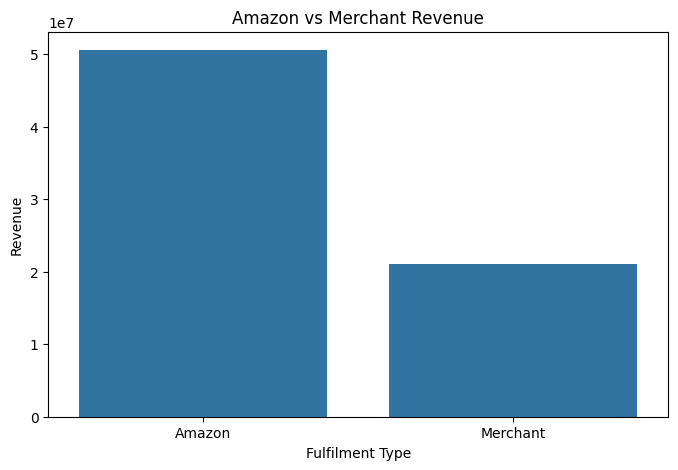

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=fulfilment_revenue,
    x='Fulfilment',
    y='Amount'
)

plt.title("Amazon vs Merchant Revenue")
plt.xlabel("Fulfilment Type")
plt.ylabel("Revenue")

plt.show()

Improving order processing for faster
deliveries.

Find Bottlenecks (Where delays happen)

In [ ]:
processing_issues = df[df['Status'].str.contains('Pending|Waiting|Picked Up|Shipping', case=False, na=False)]

print(processing_issues['Status'].value_counts())

Status
shipped - picked up              973
pending                          658
pending - waiting for pick up    281
shipping                           8
Name: count, dtype: int64


Processing Delay Rate

In [ ]:
total_orders = len(df)

processing_delay_rate = (len(processing_issues) / total_orders) * 100

print("Processing Delay Rate: {:.2f}%".format(processing_delay_rate))

Processing Delay Rate: 1.49%


Delay by Fulfilment (KEY INSIGHT)

In [ ]:
delay_by_fulfilment = processing_issues.groupby('Fulfilment')['Order ID'].count().reset_index()

print(delay_by_fulfilment)

  Fulfilment  Order ID
0     Amazon       423
1   Merchant      1497


Delay by Location (WHERE problem is)

In [ ]:
delay_by_city = processing_issues.groupby('ship-city')['Order ID'].count().reset_index()

delay_by_city = delay_by_city.sort_values(by='Order ID', ascending=False).head(10)

print(delay_by_city)

     ship-city  Order ID
58   Bengaluru       141
201  Hyderabad       140
101    Chennai        90
374  New Delhi        87
346     Mumbai        84
282    Kolkata        50
425       Pune        47
176   Gurugram        33
310    Lucknow        24
161  Ghaziabad        24


Visualization (Top Delay Cities)

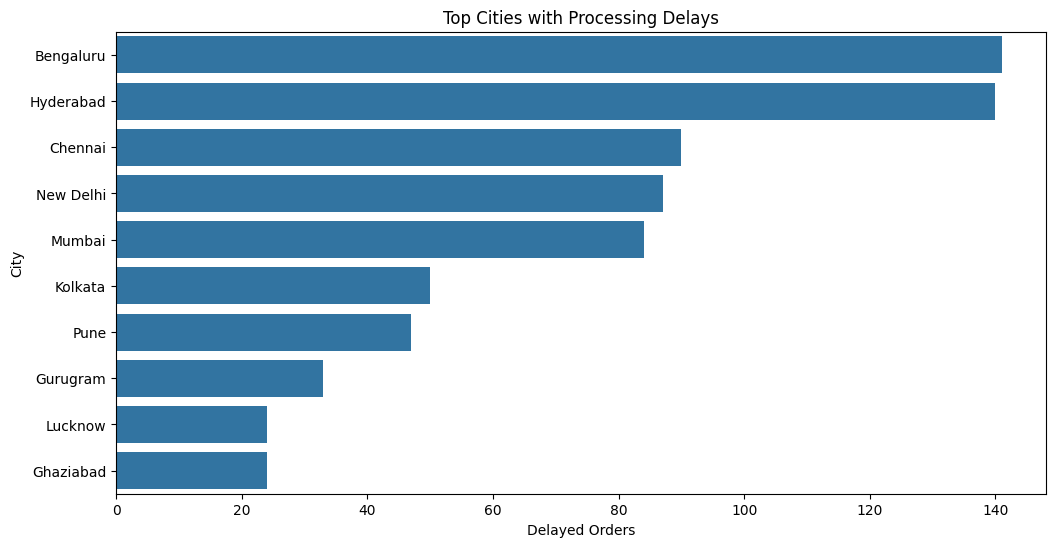

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=delay_by_city,
    x='Order ID',
    y='ship-city'
)

plt.title("Top Cities with Processing Delays")
plt.xlabel("Delayed Orders")
plt.ylabel("City")

plt.show()

% of orders moving smoothly

In [ ]:
fast_orders = df[df['Status_Clean'] == 'Shipped']

fast_rate = (len(fast_orders) / len(df)) * 100

print("Fast Delivery Rate: {:.2f}%".format(fast_rate))

Fast Delivery Rate: 82.65%


# PRODUCT MANAGEMENT & INVENTORY OPTIMIZATION


Identifying high-demand product
categories

Category-wise Total Demand (Quantity)

In [ ]:
category_demand = df.groupby('Category')['Qty'].sum().reset_index()

category_demand = category_demand.sort_values(by='Qty', ascending=False)

print(category_demand.head(10))

        Category    Qty
6            Set  45277
4          Kurta  45035
8  Western Dress  13942
7            Top   9899
3   Ethnic Dress   1052
0         Blouse    864
1         Bottom    398
5          Saree    152
2        Dupatta      3


Category-wise Revenue (High Value Demand)

In [ ]:
category_revenue = df.groupby('Category')['Amount'].sum().reset_index()

category_revenue = category_revenue.sort_values(by='Amount', ascending=False)

print(category_revenue.head(10))

        Category       Amount
6            Set  35713959.14
4          Kurta  19412784.48
8  Western Dress  10202765.00
7            Top   4901444.00
3   Ethnic Dress    731516.00
0         Blouse    418389.00
1         Bottom    135453.00
5          Saree    114694.00
2        Dupatta       915.00


Top Categories (Clean Table)

In [ ]:
top_categories = category_demand.head(10)

print(top_categories)

        Category    Qty
6            Set  45277
4          Kurta  45035
8  Western Dress  13942
7            Top   9899
3   Ethnic Dress   1052
0         Blouse    864
1         Bottom    398
5          Saree    152
2        Dupatta      3


Visualization (Demand by Category)

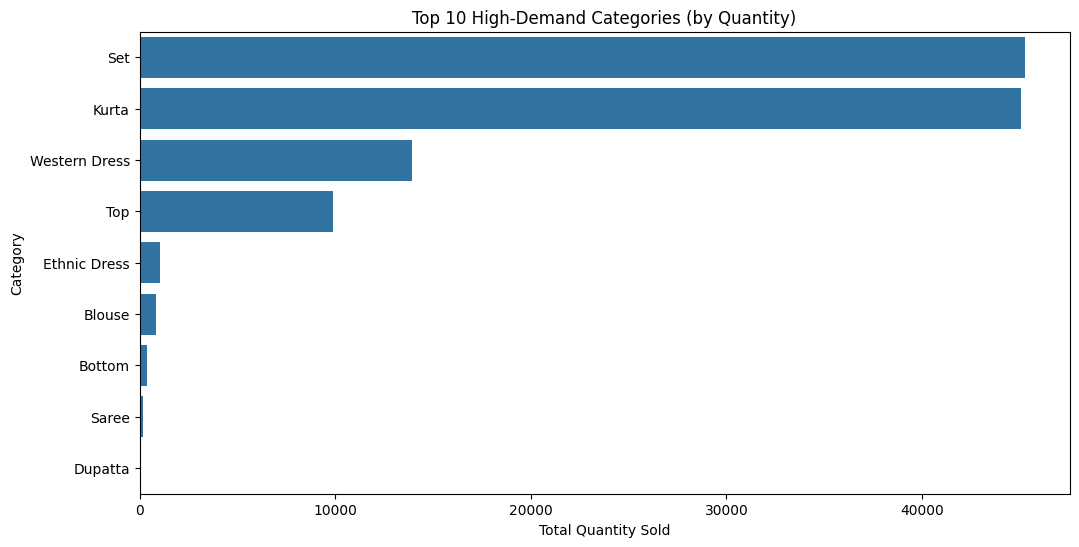

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_categories,
    x='Qty',
    y='Category'
)

plt.title("Top 10 High-Demand Categories (by Quantity)")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Category")

plt.show()

Visualization (Revenue by Category)

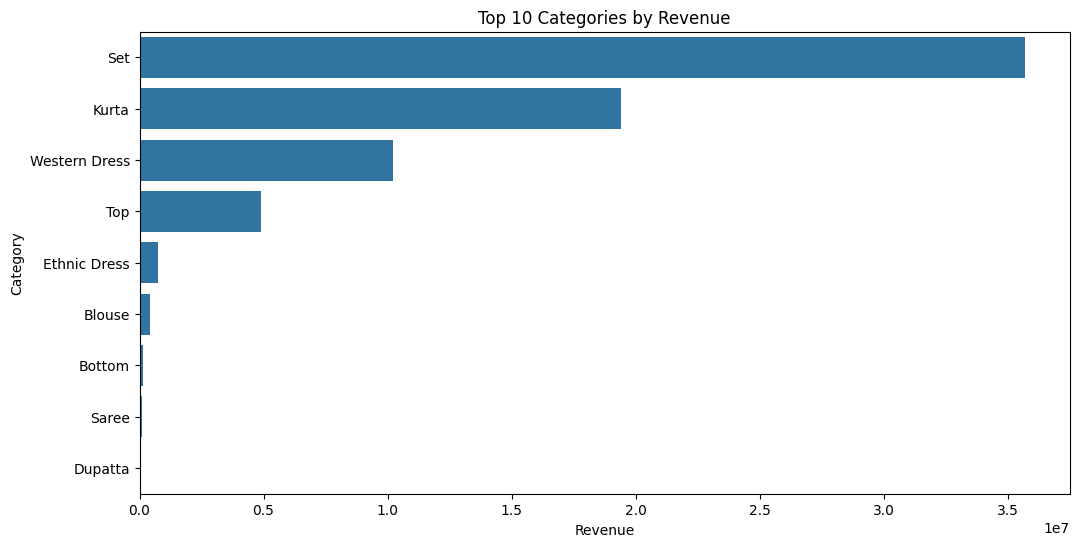

In [ ]:
top_rev_categories = category_revenue.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_rev_categories,
    x='Amount',
    y='Category'
)

plt.title("Top 10 Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.show()

top category per month

In [ ]:
monthly_category = df.groupby(['Month_Name', 'Category'])['Qty'].sum().reset_index()

monthly_category = monthly_category.sort_values(['Month_Name', 'Qty'], ascending=[True, False])

print(monthly_category.head(10))

   Month_Name       Category    Qty
4       March          Kurta     71
6       March            Set     68
7       March            Top      9
8       March  Western Dress      6
0       March         Blouse      1
3       March   Ethnic Dress      1
1       March         Bottom      0
2       March        Dupatta      0
5       March          Saree      0
15      April            Set  18138


/tmp/ipykernel_7328/168191156.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_category = df.groupby(['Month_Name', 'Category'])['Qty'].sum().reset_index()


Analyzing the average quantity ordered
for efficient stock management.

Overall Average Quantity

In [ ]:
avg_qty = df['Qty'].mean()

print("Average Quantity per Order:", round(avg_qty, 2))

Average Quantity per Order: 0.9


Average Quantity by Category

In [ ]:
category_avg_qty = df.groupby('Category')['Qty'].mean().reset_index()

category_avg_qty = category_avg_qty.sort_values(by='Qty', ascending=False)

print(category_avg_qty.head(10))

        Category       Qty
2        Dupatta  1.000000
0         Blouse  0.933045
7            Top  0.932285
5          Saree  0.926829
3   Ethnic Dress  0.908463
1         Bottom  0.904545
4          Kurta  0.903428
6            Set  0.900820
8  Western Dress  0.899832


Average Quantity by Customer Type

In [ ]:
customer_avg_qty = df.groupby('Customer_Type')['Qty'].mean().reset_index()

print(customer_avg_qty)

  Customer_Type       Qty
0           B2B  0.965557
1           B2C  0.904235


Visualization (Category-wise Avg Quantity)

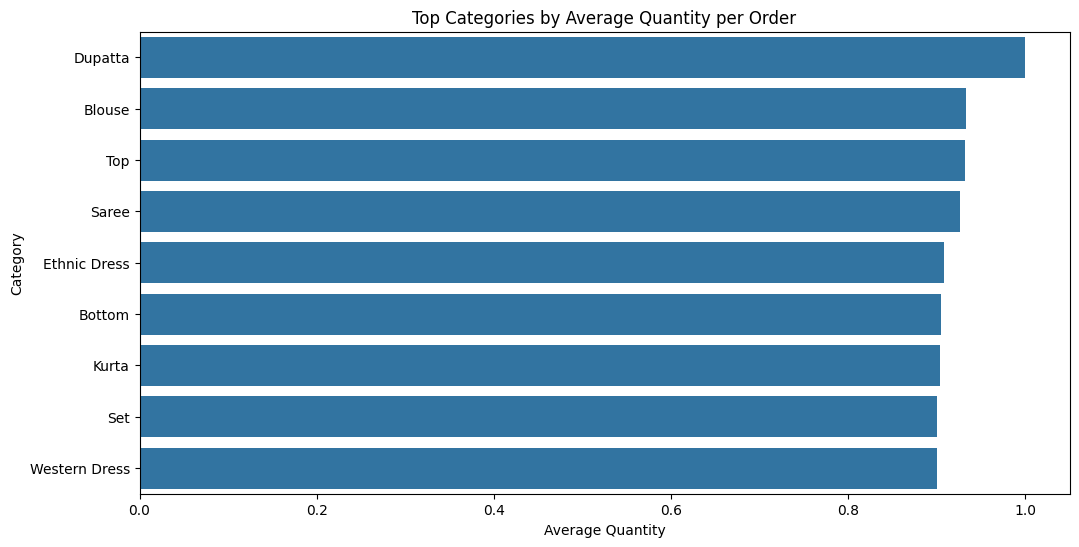

In [ ]:
plt.figure(figsize=(12,6))

top_categories = category_avg_qty.head(10)

sns.barplot(
    data=top_categories,
    x='Qty',
    y='Category'
)

plt.title("Top Categories by Average Quantity per Order")
plt.xlabel("Average Quantity")
plt.ylabel("Category")

plt.show()

seasonal demand patterns

In [ ]:
monthly_avg_qty = df.groupby(['Month_Name'])['Qty'].mean().reset_index()

print(monthly_avg_qty)

  Month_Name       Qty
0      March  0.912281
1      April  0.901232
2        May  0.904383
3       June  0.909361


/tmp/ipykernel_7328/434537316.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg_qty = df.groupby(['Month_Name'])['Qty'].mean().reset_index()


Enhancing inventory control to prevent
stockouts or overstocking.

Demand per Product (SKU level)

In [ ]:
sku_demand = df.groupby('SKU')['Qty'].sum().reset_index()

sku_demand = sku_demand.sort_values(by='Qty', ascending=False)

print(sku_demand.head(10))

                  SKU  Qty
4548     JNE3797-KR-L  661
4549     JNE3797-KR-M  560
4550     JNE3797-KR-S  503
2746     JNE3405-KR-L  485
1346      J0230-SKD-M  469
1347      J0230-SKD-S  421
4551    JNE3797-KR-XL  416
2748     JNE3405-KR-S  399
4552    JNE3797-KR-XS  386
6305  SET268-KR-NP-XL  373


Average Demand (for baseline stock)

In [ ]:
avg_sku_demand = df.groupby('SKU')['Qty'].mean().reset_index()

avg_sku_demand = avg_sku_demand.sort_values(by='Qty', ascending=False)

print(avg_sku_demand.head(10))

                    SKU  Qty
58        BL017-63BLACK  8.0
5688  SET083-KR-PP-XXXL  3.0
62          BL020-71RED  3.0
2600  JNE3365-KR-1052-M  3.0
1133         J0184-KR-S  2.0
3173     JNE3503-KR-XXL  2.0
3638    JNE3629-KR-XXXL  2.0
90             BL086-XL  2.0
6271     SET263-KR-NP-S  2.0
6555    SET315-KR-PP-XL  2.0


Identify High & Low Demand Products

In [ ]:
high_demand = sku_demand[sku_demand['Qty'] > sku_demand['Qty'].quantile(0.75)]
low_demand = sku_demand[sku_demand['Qty'] < sku_demand['Qty'].quantile(0.25)]

print("High Demand SKUs:\n", high_demand.head())
print("\nLow Demand SKUs:\n", low_demand.head())

High Demand SKUs:
                SKU  Qty
4548  JNE3797-KR-L  661
4549  JNE3797-KR-M  560
4550  JNE3797-KR-S  503
2746  JNE3405-KR-L  485
1346   J0230-SKD-M  469

Low Demand SKUs:
                    SKU  Qty
7136    SET431-KR-NP-L    2
7124    SET414-KR-NP-S    2
7123    SET414-KR-NP-M    2
7113  SET410-KR-NP-XXL    2
1470    J0249-SKD-XXXL    2


Monthly Demand Trend (Stock Planning)

In [ ]:
monthly_sku = df.groupby(['Month_Name', 'SKU'])['Qty'].sum().reset_index()

print(monthly_sku.head())

  Month_Name             SKU  Qty
0      March     AN201-RED-M    0
1      March    AN201-RED-XL    0
2      March   AN201-RED-XXL    0
3      March  AN202-ORANGE-M    0
4      March  AN202-ORANGE-S    0


/tmp/ipykernel_7328/1242309311.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sku = df.groupby(['Month_Name', 'SKU'])['Qty'].sum().reset_index()


Stock Risk (Stockout Indicator)
High demand + low frequency = risk

In [ ]:
sku_orders = df.groupby('SKU')['Order ID'].count().reset_index()

stock_risk = pd.merge(sku_demand, sku_orders, on='SKU')

stock_risk.columns = ['SKU', 'Total_QTY', 'Order_Count']

stock_risk = stock_risk.sort_values(by='Total_QTY', ascending=False)

print(stock_risk.head(10))

               SKU  Total_QTY  Order_Count
0     JNE3797-KR-L        661          773
1     JNE3797-KR-M        560          656
2     JNE3797-KR-S        503          587
3     JNE3405-KR-L        485          535
4      J0230-SKD-M        469          507
5      J0230-SKD-S        421          452
6    JNE3797-KR-XL        416          474
7     JNE3405-KR-S        399          441
8    JNE3797-KR-XS        386          431
9  SET268-KR-NP-XL        373          386


Visualization (Top Demand SKUs)

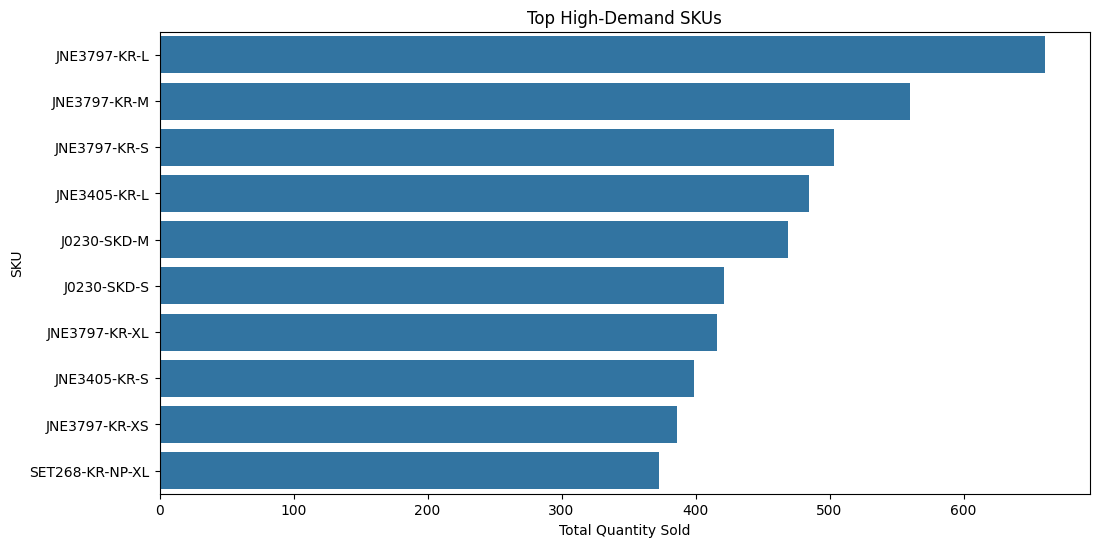

In [ ]:
top_skus = sku_demand.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_skus,
    x='Qty',
    y='SKU'
)

plt.title("Top High-Demand SKUs")
plt.xlabel("Total Quantity Sold")
plt.ylabel("SKU")

plt.show()

# CUSTOMER SATISFACTION & RETURNS



Investigating high return and cancellation
rates.


Overall Cancellation & Return Rate

In [ ]:
total_orders = len(df)

cancelled = len(df[df['Status_Clean'] == 'Cancelled'])
returned = len(df[df['Status'].str.contains('Returned|Returning', case=False, na=False)])

cancel_rate = (cancelled / total_orders) * 100
return_rate = (returned / total_orders) * 100

print("Cancellation Rate: {:.2f}%".format(cancel_rate))
print("Return Rate: {:.2f}%".format(return_rate))

Cancellation Rate: 15.85%
Return Rate: 1.63%


Monthly Trend (Cancellations + Returns)

In [ ]:
monthly_issues = df[
    (df['Status_Clean'] == 'Cancelled') |
    (df['Status'].str.contains('Returned|Returning', case=False, na=False))
]

monthly_issues = monthly_issues.groupby(['Month', 'Month_Name'], as_index=False)['Order ID'].count()

monthly_issues = monthly_issues.sort_values('Month')

print(monthly_issues)

    Month Month_Name  Order ID
0       3      March        19
1       3      April         0
2       3        May         0
3       3       June         0
4       4      March         0
5       4      April      8034
6       4        May         0
7       4       June         0
8       5      March         0
9       5      April         0
10      5        May      6599
11      5       June         0
12      6      March         0
13      6      April         0
14      6        May         0
15      6       June      5787


/tmp/ipykernel_7328/2299702318.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_issues = monthly_issues.groupby(['Month', 'Month_Name'], as_index=False)['Order ID'].count()


By Category

In [ ]:
category_issues = df[
    (df['Status_Clean'] == 'Cancelled') |
    (df['Status'].str.contains('Returned|Returning', case=False, na=False))
].groupby('Category')['Order ID'].count().reset_index()

category_issues = category_issues.sort_values(by='Order ID', ascending=False)

print(category_issues.head(10))

        Category  Order ID
5            Set      8179
3          Kurta      8004
7  Western Dress      2468
6            Top      1410
2   Ethnic Dress       162
0         Blouse       128
1         Bottom        66
4          Saree        22


By Fulfilment (Amazon vs Merchant)

In [ ]:
fulfilment_issues = df[
    (df['Status_Clean'] == 'Cancelled') |
    (df['Status'].str.contains('Returned|Returning', case=False, na=False))
].groupby('Fulfilment')['Order ID'].count().reset_index()

print(fulfilment_issues)

  Fulfilment  Order ID
0     Amazon     11474
1   Merchant      8965


By Location

In [ ]:
location_issues = df[
    (df['Status_Clean'] == 'Cancelled') |
    (df['Status'].str.contains('Returned|Returning', case=False, na=False))
].groupby('ship-city')['Order ID'].count().reset_index()

location_issues = location_issues.sort_values(by='Order ID', ascending=False).head(10)

print(location_issues)

      ship-city  Order ID
317   Bengaluru      1541
982   Hyderabad      1430
1825  New Delhi       945
1670     Mumbai       911
512     Chennai       896
2060       Pune       655
1332    Kolkata       428
2477      Thane       283
1473    Lucknow       282
911    Gurugram       244


Visualization

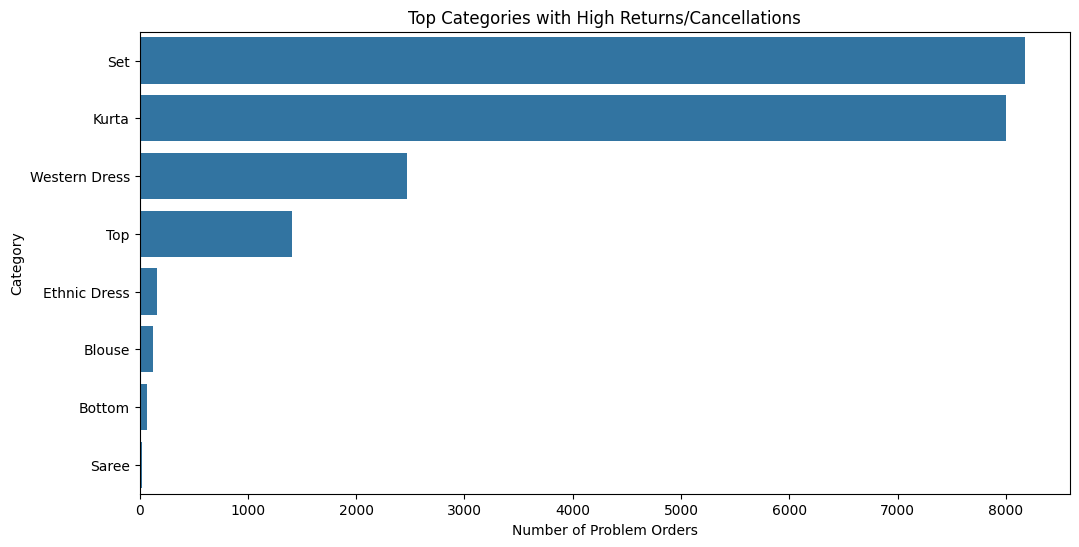

In [ ]:
top_categories = category_issues.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_categories,
    x='Order ID',
    y='Category'
)

plt.title("Top Categories with High Returns/Cancellations")
plt.xlabel("Number of Problem Orders")
plt.ylabel("Category")

plt.show()

Identifying problematic
products/categories to enhance quality.

Problematic Orders Filter

In [ ]:
problem_orders = df[
    (df['Status_Clean'] == 'Cancelled') |
    (df['Status'].str.contains('Returned|Returning|Damaged|Rejected', case=False, na=False))
]

Problematic Categories

In [ ]:
problem_categories = problem_orders.groupby('Category')['Order ID'].count().reset_index()

problem_categories = problem_categories.sort_values(by='Order ID', ascending=False)

print(problem_categories.head(10))

        Category  Order ID
5            Set      8179
3          Kurta      8004
7  Western Dress      2469
6            Top      1410
2   Ethnic Dress       162
0         Blouse       128
1         Bottom        66
4          Saree        22


Problematic Products

In [ ]:
problem_skus = problem_orders.groupby('SKU')['Order ID'].count().reset_index()

problem_skus = problem_skus.sort_values(by='Order ID', ascending=False)

print(problem_skus.head(10))

                SKU  Order ID
2730   JNE3797-KR-L       152
2731   JNE3797-KR-M       125
2732   JNE3797-KR-S       122
1574   JNE3405-KR-L        88
2733  JNE3797-KR-XL        85
2734  JNE3797-KR-XS        76
1575   JNE3405-KR-M        76
660     J0230-SKD-M        75
100     J0003-SET-S        73
99      J0003-SET-M        72


Problem Rate

In [ ]:
total_category_orders = df.groupby('Category')['Order ID'].count().reset_index()

problem_category_count = problem_orders.groupby('Category')['Order ID'].count().reset_index()

problem_rate = pd.merge(total_category_orders, problem_category_count, on='Category', how='left')

problem_rate.columns = ['Category', 'Total_Orders', 'Problem_Orders']

problem_rate['Problem_Orders'] = problem_rate['Problem_Orders'].fillna(0)

problem_rate['Problem_Rate (%)'] = (problem_rate['Problem_Orders'] / problem_rate['Total_Orders']) * 100

problem_rate = problem_rate.sort_values(by='Problem_Rate (%)', ascending=False)

print(problem_rate.head(10))

        Category  Total_Orders  Problem_Orders  Problem_Rate (%)
6            Set         50262          8179.0         16.272731
4          Kurta         49849          8004.0         16.056491
8  Western Dress         15494          2469.0         15.935201
1         Bottom           440            66.0         15.000000
3   Ethnic Dress          1158           162.0         13.989637
0         Blouse           926           128.0         13.822894
5          Saree           164            22.0         13.414634
7            Top         10618          1410.0         13.279337
2        Dupatta             3             0.0          0.000000


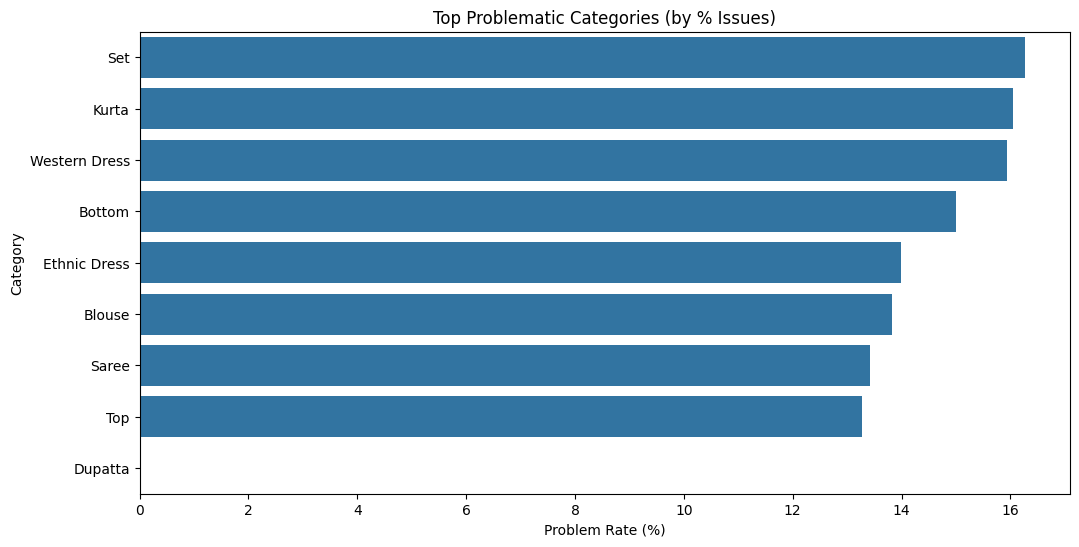

In [ ]:
top_problem = problem_rate.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_problem,
    x='Problem_Rate (%)',
    y='Category'
)

plt.title("Top Problematic Categories (by % Issues)")
plt.xlabel("Problem Rate (%)")
plt.ylabel("Category")

plt.show()

Improving customer experience through
better service policies.

Measure Customer Experience (Proxy Metrics)

In [ ]:
cx_issues = df[
    (df['Status_Clean'] == 'Cancelled') |
    (df['Status'].str.contains('Returned|Returning|Damaged|Lost|Rejected', case=False, na=False))
]

cx_rate = (len(cx_issues) / len(df)) * 100

print("Customer Issue Rate: {:.2f}%".format(cx_rate))

Customer Issue Rate: 15.86%


Experience by Customer Type (B2B vs B2C)

In [ ]:
cx_by_customer = cx_issues.groupby('Customer_Type')['Order ID'].count().reset_index()

print(cx_by_customer)

  Customer_Type  Order ID
0           B2B        82
1           B2C     20363


Experience by Fulfilment

In [ ]:
cx_by_fulfilment = cx_issues.groupby('Fulfilment')['Order ID'].count().reset_index()

print(cx_by_fulfilment)

  Fulfilment  Order ID
0     Amazon     11474
1   Merchant      8971


Experience by Location

In [ ]:
cx_by_city = cx_issues.groupby('ship-city')['Order ID'].count().reset_index()

cx_by_city = cx_by_city.sort_values(by='Order ID', ascending=False).head(10)

print(cx_by_city)

      ship-city  Order ID
317   Bengaluru      1545
983   Hyderabad      1430
1826  New Delhi       945
1671     Mumbai       911
513     Chennai       897
2061       Pune       655
1333    Kolkata       428
2478      Thane       283
1474    Lucknow       282
912    Gurugram       244


Visualization (Customer Issues by Fulfilment)

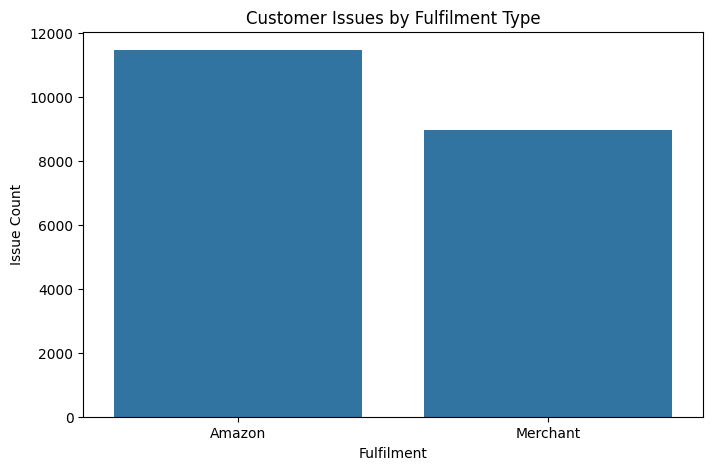

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=cx_by_fulfilment,
    x='Fulfilment',
    y='Order ID'
)

plt.title("Customer Issues by Fulfilment Type")
plt.xlabel("Fulfilment")
plt.ylabel("Issue Count")

plt.show()

-------------------------------------

# Key Insights

1. I performed end-to-end EDA where I found that total revenue generated was ₹71.77M, indicating strong overall business performance.

2. I found that sales were highest in April (₹26.6M) followed by May (₹23.9M) and June(₹21M), showing a declining trend after peak demand.

3. I observed that the dataset contains ~128k total transactions with ~120k unique orders, indicating multiple items per order.

4. I found that Average Order value(AOV) is ~₹596, reflecting consistent customer spending behaviour.

5. Weekly analysis showed that Tuesday generated the highest revenue (~ ₹10.27M), while Thrusday had the lowest (~ ₹9.64M), indicating variation in customer activity across the week.

6. From category analysis, I found that "Set" category geberated the highest revenue (~ ₹35.77M) followed by Kurta (~ ₹19.47M), making them key revenue drivers.

7. I observed that Bengluru (~ ₹6.64M), Hyderabad (~ ₹4.49M), and Mumbai (~ ₹3.4M) are the top-performing cities contributing the most revenue.

8. State-level analysis showed that Maharashtra (~ ₹12.23M) and Karnataka (~ ₹9.64M) are the highest revenue-generating regions.

9. I found that the total cancelled orders are 18,338 with a cancellation rate of ~14.22%, indicating significant operational inefficiency.

10. Fulfilment analysis showed that Amazon handled ~89K orders compared to ~39K by merchants, indicating higher dependency on Amazon logistics.

Recommendations

Prioritize Amazon fulfilment to improve delivery success and reduce cancellations

Improve product quality and descriptions to minimize returns and customer dissatisfaction

Optimize inventory for high-demand categories like Set and Kurta to avoid stockouts

Focus on top-performing cities (Bengaluru, Hyderabad, Mumbai) for targeted growth

Reduce operational delays by improving logistics in low-performing regions
Use weekday trends (e.g., high sales on Tuesday) for better campaign planning

Implement strategies to reduce high cancellation rate (~15.85%)

Leverage B2B customers for bulk sales and stable revenue growth

Continuously monitor key KPIs like revenue, cancellations, and delivery performance

Conclusion

This analysis highlights that the business demonstrates strong revenue performance with peak sales in April and consistent contribution from key categories like Set and Kurta. However, challenges such as a relatively high cancellation rate, delivery inefficiencies, and issues in certain product segments impact overall performance and customer experience. By leveraging data-driven insights to optimize fulfilment, inventory, and customer strategies, the business can improve operational efficiency and profitability. Continuous monitoring of key metrics will be essential to sustain growth and enhance customer satisfaction over time.

--------------------------------------------------------------------------------

-------------------------------------

In [ ]:
from google.colab import files
df.to_csv("Sales_data.csv", index=False)
files.download("Sales_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
total_revenue = df['Amount'].sum()
total_orders = df['Order ID'].nunique()
total_cancelled = df[df['Status'] == 'cancelled']['Order ID'].nunique()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Total Cancelled Orders:", total_cancelled)

Total Revenue: 71631919.62
Total Orders: 120322
Total Cancelled Orders: 17189
